# U.S. STORM DAMAGE ANALYSIS

## Goal
Analyze a decade of U.S. storm event data to identify patterns in financial damage, human impact, and geographic exposure across the country. The goal of this analysis is to understand which storm event types, states, and time periods carry the greatest risk and to translate those findings into actionable insights for institutions like insurers, emergency managers, and city planners.

## Dataset
Source: NOAA National Centers for Environmental Information (NCEI) Storm Events Database

Time Period: 2015 through 2024

Files: 10 separate CSV files, one per year

Total Records: 110,141 damage causing events after filtering

## Methodology
Damage Parsing: NOAA stores damage values as shorthand strings like 250K or 1.5M. A Python parser was written to convert these into true numeric dollar values for accurate aggregation across all 10 years of data.

Estimating People Affected: Direct casualties from the dataset capture deaths and injuries but do not reflect the full population impacted by property damage. To estimate broader impact, property damage was divided by the U.S. median home value of $229,800 from the 2020 Census to estimate homes affected, then multiplied by the average household size of 2.53 people. I also want to note that this method does not account for renters, commercial property, or infrastructure damage.

Filtering: The dataset was filtered to damage causing events only, meaning events that reported at least some property or crop damage. This removed noise from recorded events that caused no measurable financial impact and kept the focus on events that directly affected communities.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import json
import urllib.request
import folium
import numpy as np
from folium.plugins import HeatMap
import branca.colormap as cm
import plotly.graph_objects as go
from plotly.subplots import make_subplots


## 1. Import Data

In [2]:
DATA_FOLDER = r'C:\Users\josep\Downloads\Storm Data'

FILES = [
    'StormEvents_details-ftp_v1.0_d2015_c20260323.csv',
    'StormEvents_details-ftp_v1.0_d2016_c20260323.csv',
    'StormEvents_details-ftp_v1.0_d2017_c20260519.csv',
    'StormEvents_details-ftp_v1.0_d2018_c20260323.csv',
    'StormEvents_details-ftp_v1.0_d2019_c20260323.csv',
    'StormEvents_details-ftp_v1.0_d2020_c20260323.csv',
    'StormEvents_details-ftp_v1.0_d2021_c20260323.csv',
    'StormEvents_details-ftp_v1.0_d2022_c20260323.csv',
    'StormEvents_details-ftp_v1.0_d2023_c20260323.csv',
    'StormEvents_details-ftp_v1.0_d2024_c20260421.csv',
]

frames = []
for filename in FILES:
    path = os.path.join(DATA_FOLDER, filename)
    df_tmp = pd.read_csv(path, low_memory=False)
    frames.append(df_tmp)
    print(f'✔ {filename:55s} → {len(df_tmp):,} rows')

df = pd.concat(frames, ignore_index=True)

print(f'\n Combined dataset: {len(df):,} rows × {df.shape[1]} columns')
print(f'Years present: {sorted(df["YEAR"].dropna().unique().astype(int).tolist())}')

✔ StormEvents_details-ftp_v1.0_d2015_c20260323.csv        → 57,907 rows
✔ StormEvents_details-ftp_v1.0_d2016_c20260323.csv        → 56,005 rows
✔ StormEvents_details-ftp_v1.0_d2017_c20260519.csv        → 57,041 rows
✔ StormEvents_details-ftp_v1.0_d2018_c20260323.csv        → 62,699 rows
✔ StormEvents_details-ftp_v1.0_d2019_c20260323.csv        → 67,864 rows
✔ StormEvents_details-ftp_v1.0_d2020_c20260323.csv        → 61,281 rows
✔ StormEvents_details-ftp_v1.0_d2021_c20260323.csv        → 61,389 rows
✔ StormEvents_details-ftp_v1.0_d2022_c20260323.csv        → 69,887 rows
✔ StormEvents_details-ftp_v1.0_d2023_c20260323.csv        → 75,593 rows
✔ StormEvents_details-ftp_v1.0_d2024_c20260421.csv        → 69,801 rows

 Combined dataset: 639,467 rows × 51 columns
Years present: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


## 2. Clean Data

In [3]:
# Keep only relevant columns
KEEP_COLS = [
    'YEAR', 'MONTH_NAME', 'STATE', 'CZ_NAME', 'EVENT_TYPE',
    'INJURIES_DIRECT', 'INJURIES_INDIRECT',
    'DEATHS_DIRECT', 'DEATHS_INDIRECT',
    'DAMAGE_PROPERTY', 'DAMAGE_CROPS',
    'BEGIN_LAT', 'BEGIN_LON'
]

df = df[[c for c in KEEP_COLS if c in df.columns]].copy()

print(f'Columns kept: {list(df.columns)}')
print(f'Shape after column drop: {df.shape}')

# Parse damage strings (e.g. "250K" → 250000) 
def parse_damage(val):
    if pd.isna(val) or str(val).strip() in ('', '0', 'nan'):
        return 0.0
    val = str(val).strip().upper().replace(',', '')
    multipliers = {'K': 1_000, 'M': 1_000_000, 'B': 1_000_000_000}
    if val[-1] in multipliers:
        try:
            return float(val[:-1]) * multipliers[val[-1]]
        except ValueError:
            return 0.0
    try:
        return float(val)
    except ValueError:
        return 0.0

df['DAMAGE_PROPERTY_USD'] = df['DAMAGE_PROPERTY'].apply(parse_damage)
df['DAMAGE_CROPS_USD']    = df['DAMAGE_CROPS'].apply(parse_damage)
df['TOTAL_DAMAGE_USD']    = df['DAMAGE_PROPERTY_USD'] + df['DAMAGE_CROPS_USD']

df.drop(columns=['DAMAGE_PROPERTY', 'DAMAGE_CROPS'], inplace=True)

# Clean up remaining columns
for col in ['INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

df['TOTAL_INJURIES'] = df['INJURIES_DIRECT'] + df['INJURIES_INDIRECT']
df['TOTAL_DEATHS']   = df['DEATHS_DIRECT']   + df['DEATHS_INDIRECT']
df['STATE']          = df['STATE'].str.title().str.strip()
df['YEAR']           = pd.to_numeric(df['YEAR'], errors='coerce')

# Filter to damage events only
df_damage = df[df['TOTAL_DAMAGE_USD'] > 0].copy()

print(f'\nTotal events (2015–2024):         {len(df):,}')
print(f'Events with reported damage:      {len(df_damage):,}')
print(f'Total reported damage:            ${df_damage["TOTAL_DAMAGE_USD"].sum():,.0f}')
df.head(3)

Columns kept: ['YEAR', 'MONTH_NAME', 'STATE', 'CZ_NAME', 'EVENT_TYPE', 'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'BEGIN_LAT', 'BEGIN_LON']
Shape after column drop: (639467, 13)

Total events (2015–2024):         639,467
Events with reported damage:      130,865
Total reported damage:            $260,988,446,050


,YEAR,MONTH_NAME,STATE,CZ_NAME,EVENT_TYPE,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,BEGIN_LAT,BEGIN_LON,DAMAGE_PROPERTY_USD,DAMAGE_CROPS_USD,TOTAL_DAMAGE_USD,TOTAL_INJURIES,TOTAL_DEATHS
0,2015,September,Illinois,WILL,Tornado,0,0,0,0,41.4164,-87.86,70000.0,0.0,70000.0,0,0
1,2015,January,New Hampshire,EASTERN HILLSBOROUGH,Winter Storm,0,0,0,0,NaN,NaN,0.0,0.0,0.0,0,0
2,2015,January,New Hampshire,EASTERN HILLSBOROUGH,Heavy Snow,0,0,0,0,NaN,NaN,0.0,0.0,0.0,0,0


## 3. Incident count & damage breakdown by event type and year

In [4]:
# People Impacted + Damage by Event Category Through the Years
AVG_HOME_VALUE     = 229800
AVG_HOUSEHOLD_SIZE = 2.53

df_damage['TOTAL_CASUALTIES']    = (
    df_damage['INJURIES_DIRECT'] +
    df_damage['INJURIES_INDIRECT'] +
    df_damage['DEATHS_DIRECT'] +
    df_damage['DEATHS_INDIRECT']
)
df_damage['EST_HOMES_AFFECTED']  = df_damage['DAMAGE_PROPERTY_USD'] / AVG_HOME_VALUE
df_damage['EST_PEOPLE_AFFECTED'] = (df_damage['EST_HOMES_AFFECTED'] * AVG_HOUSEHOLD_SIZE).round(0).astype(int)

impact_summary = (
    df_damage.groupby(['YEAR', 'EVENT_TYPE'])
    .agg(
        Incidents        =('EVENT_TYPE',          'count'),
        Total_Damage     =('TOTAL_DAMAGE_USD',     'sum'),
        Total_Deaths     =('TOTAL_DEATHS',         'sum'),
        Total_Injuries   =('TOTAL_INJURIES',       'sum'),
        Total_Casualties =('TOTAL_CASUALTIES',     'sum'),
        Est_People       =('EST_PEOPLE_AFFECTED',  'sum'))
        .reset_index())

impact_summary['YEAR']           = impact_summary['YEAR'].astype(int)
impact_summary['Total_Impacted'] = impact_summary['Total_Casualties'] + impact_summary['Est_People']

# Helper to format damage 
def fmt_dmg(val):
    if val >= 1e9:  return f'${val/1e9:.2f}B'
    if val >= 1e6:  return f'${val/1e6:.1f}M'
    return f'${val:,.0f}'

# Print combined output
print('=' * 90)
print('  STORM IMPACT SUMMARY BY EVENT TYPE & YEAR (2015–2024)')
print('=' * 90)

for year in sorted(impact_summary['YEAR'].unique()):
    year_df = (
        impact_summary[impact_summary['YEAR'] == year]
        .sort_values('Total_Damage', ascending=False)
        .head(10)
    )
    yr_damage   = year_df['Total_Damage'].sum()
    yr_impacted = year_df['Total_Impacted'].sum()

    print(f'\n📅 {year}  |  Total Damage: {fmt_dmg(yr_damage)}  |  Est. People Impacted: {yr_impacted:,.0f}')
    print(f'   {"Event Type":<28} {"#Events":>7} {"Damage":>10} {"Deaths":>7} {"Injuries":>9} {"Est.Affected":>13} {"Total Impacted":>15}')
    print(f'   {"-"*28} {"-"*7} {"-"*10} {"-"*7} {"-"*9} {"-"*13} {"-"*15}')

    for _, row in year_df.iterrows():
        print(
            f'   {row["EVENT_TYPE"]:<28} '
            f'{int(row["Incidents"]):>7,} '
            f'{fmt_dmg(row["Total_Damage"]):>10} '
            f'{int(row["Total_Deaths"]):>7,} '
            f'{int(row["Total_Injuries"]):>9,} '
            f'{int(row["Est_People"]):>13,} '
            f'{int(row["Total_Impacted"]):>15,}'
        )

print('\n' + '=' * 90)
print(f'  GRAND TOTAL  |  Damage: {fmt_dmg(impact_summary["Total_Damage"].sum())}  |  Est. Impacted: {impact_summary["Total_Impacted"].sum():,.0f}')
print('=' * 90)
print('\n⚠️  Est. Affected = property damage ÷ median home value ($229,800) × avg household size (2.53)')

  STORM IMPACT SUMMARY BY EVENT TYPE & YEAR (2015–2024)

📅 2015  |  Total Damage: $4.91B  |  Est. People Impacted: 48,037
   Event Type                   #Events     Damage  Deaths  Injuries  Est.Affected  Total Impacted
   ---------------------------- ------- ---------- ------- --------- ------------- ---------------
   Flash Flood                    1,976     $2.13B     101        79        20,153          20,333
   Flood                            868    $866.5M      26         3         7,630           7,659
   Hail                             596    $719.5M       0         1         6,419           6,420
   Blizzard                          20    $433.7M       2         0         4,775           4,777
   Tornado                          592    $321.1M      35       892         3,496           4,423
   Thunderstorm Wind              6,628    $215.8M      19        68         1,848           1,935
   Winter Storm                     292     $90.2M       5         1         1,007    

In [6]:
import folium
import numpy as np
import pandas as pd
from folium.plugins import HeatMap, FastMarkerCluster

# Prep 
geo_df = df_damage.dropna(subset=['BEGIN_LAT','BEGIN_LON']).copy()
geo_df['BEGIN_LAT'] = pd.to_numeric(geo_df['BEGIN_LAT'], errors='coerce')
geo_df['BEGIN_LON'] = pd.to_numeric(geo_df['BEGIN_LON'], errors='coerce')
geo_df = geo_df.dropna(subset=['BEGIN_LAT','BEGIN_LON'])

def fmt_dmg(val):
    if val >= 1e9:  return f'${val/1e9:.2f}B'
    if val >= 1e6:  return f'${val/1e6:.1f}M'
    return f'${val:,.0f}'

def severity(damage):
    if damage >= 1_000_000_000: return 'Catastrophic', '#67000d', 18
    if damage >= 100_000_000:   return 'Severe',       '#cb181d', 14
    if damage >= 10_000_000:    return 'Major',        '#ef3b2c', 10
    if damage >= 1_000_000:     return 'Moderate',     '#fc8d59',  7
    if damage >= 100_000:       return 'Minor',        '#fdcc8a',  5
    return                             'Minimal',      '#ffffb2',  3

geo_df[['SEV_LABEL','SEV_COLOR','SEV_RADIUS']] = geo_df['TOTAL_DAMAGE_USD'].apply(
    lambda x: pd.Series(severity(x))
)

print(f'Plotting {len(geo_df):,} events...')
print(geo_df['SEV_LABEL'].value_counts().to_string())

# Base map 
m = folium.Map(location=[39.5, -98.35], zoom_start=5, tiles='CartoDB dark_matter')

# Layer groups
layers = {
    'Catastrophic': folium.FeatureGroup(name='🔴 Catastrophic (≥$1B)',  show=True),
    'Severe':       folium.FeatureGroup(name='🔴 Severe (≥$100M)',      show=True),
    'Major':        folium.FeatureGroup(name='🟠 Major (≥$10M)',        show=True),
    'Moderate':     folium.FeatureGroup(name='🟡 Moderate (≥$1M)',      show=True),
    'Minor':        folium.FeatureGroup(name='🟡 Minor (≥$100K)',       show=False),
    'Minimal':      folium.FeatureGroup(name='⚪ Minimal (<$100K)',     show=False),
}

# High severity — individual markers with full popups 
high = geo_df[geo_df['SEV_LABEL'].isin(['Catastrophic','Severe','Major','Moderate'])]

for _, row in high.iterrows():
    folium.CircleMarker(
        location=[row['BEGIN_LAT'], row['BEGIN_LON']],
        radius=row['SEV_RADIUS'],
        color=row['SEV_COLOR'],
        fill=True,
        fill_color=row['SEV_COLOR'],
        fill_opacity=0.8,
        popup=folium.Popup(f"""
            <div style='font-family:Arial;font-size:12px;width:230px'>
                <b style='font-size:13px'>{row['EVENT_TYPE']}</b><br>
                📍 {row['CZ_NAME']}, {row['STATE']}<br>
                📅 {row['MONTH_NAME']} {int(row['YEAR'])}<br>
                <hr style='margin:4px 0'>
                💰 <b>Damage: {fmt_dmg(row['TOTAL_DAMAGE_USD'])}</b><br>
                ☠️ Deaths: {int(row['TOTAL_DEATHS'])} &nbsp;|&nbsp;
                🤕 Injuries: {int(row['TOTAL_INJURIES'])}<br>
                👥 Est. People Affected: {int(row['EST_PEOPLE_AFFECTED']):,}<br>
                ⚠️ Severity: <b>{row['SEV_LABEL']}</b>
            </div>""", max_width=250),
        tooltip=f"{row['EVENT_TYPE']} | {fmt_dmg(row['TOTAL_DAMAGE_USD'])} | {row['CZ_NAME']}, {row['STATE']}"
    ).add_to(layers[row['SEV_LABEL']])

print('✔ High-severity markers plotted')

# Low severity — fast clusters (no individual popups, too many points)
for sev in ['Minor', 'Minimal']:
    subset = geo_df[geo_df['SEV_LABEL'] == sev]
    if len(subset) > 0:
        FastMarkerCluster(
            subset[['BEGIN_LAT','BEGIN_LON']].values.tolist()
        ).add_to(layers[sev])

print('✔ Low-severity clusters plotted')

# Heatmap overlay 
heat_data = [
    [row['BEGIN_LAT'], row['BEGIN_LON'], min(row['TOTAL_DAMAGE_USD'] / 1e7, 10)]
    for _, row in geo_df.iterrows()
]
HeatMap(
    heat_data,
    name='🌡️ Damage Heatmap',
    min_opacity=0.2,
    radius=18,
    blur=25,
    show=False
).add_to(m)

print('✔ Heatmap plotted')

# Add layers
for layer in layers.values():
    layer.add_to(m)

# Legend 
legend_html = """
<div style='position:fixed;bottom:40px;left:40px;z-index:9999;
     background:#1a1a1a;padding:14px 18px;border-radius:8px;
     border:1px solid #555;font-family:Arial;color:#eee;font-size:12px;'>
  <b style='font-size:13px'>⚡ Damage Severity</b><br><br>
  <span style='color:#67000d;font-size:16px'>●</span> Catastrophic (≥$1B)<br>
  <span style='color:#cb181d;font-size:16px'>●</span> Severe (≥$100M)<br>
  <span style='color:#ef3b2c;font-size:16px'>●</span> Major (≥$10M)<br>
  <span style='color:#fc8d59;font-size:16px'>●</span> Moderate (≥$1M)<br>
  <span style='color:#fdcc8a;font-size:16px'>●</span> Minor (≥$100K)<br>
  <span style='color:#ffffb2;font-size:16px'>●</span> Minimal (&lt;$100K)<br><br>
  <span style='color:#aaa;font-size:10px'>
    Circle size = damage magnitude<br>
    Click markers for full details<br>
    Toggle layers top-right
  </span>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Layer control
folium.LayerControl(collapsed=False).add_to(m)

# Save & display
OUTPUT_MAP = r'C:\Users\josep\Downloads\Storm Data\Storm_Damage_Map.html'
m.save(OUTPUT_MAP)

print(f'\n✅ Map saved to: {OUTPUT_MAP}')
print(f'   Open Storm_Damage_Map.html in Chrome or Edge to view')

Plotting 110,141 events...
SEV_LABEL
Minimal         98158
Minor            8931
Moderate         2335
Major             568
Severe            133
Catastrophic       16
✔ High-severity markers plotted
✔ Low-severity clusters plotted
✔ Heatmap plotted

✅ Map saved to: C:\Users\josep\Downloads\Storm Data\Storm_Damage_Map.html
   Open Storm_Damage_Map.html in Chrome or Edge to view


## 4. Trend Analysis

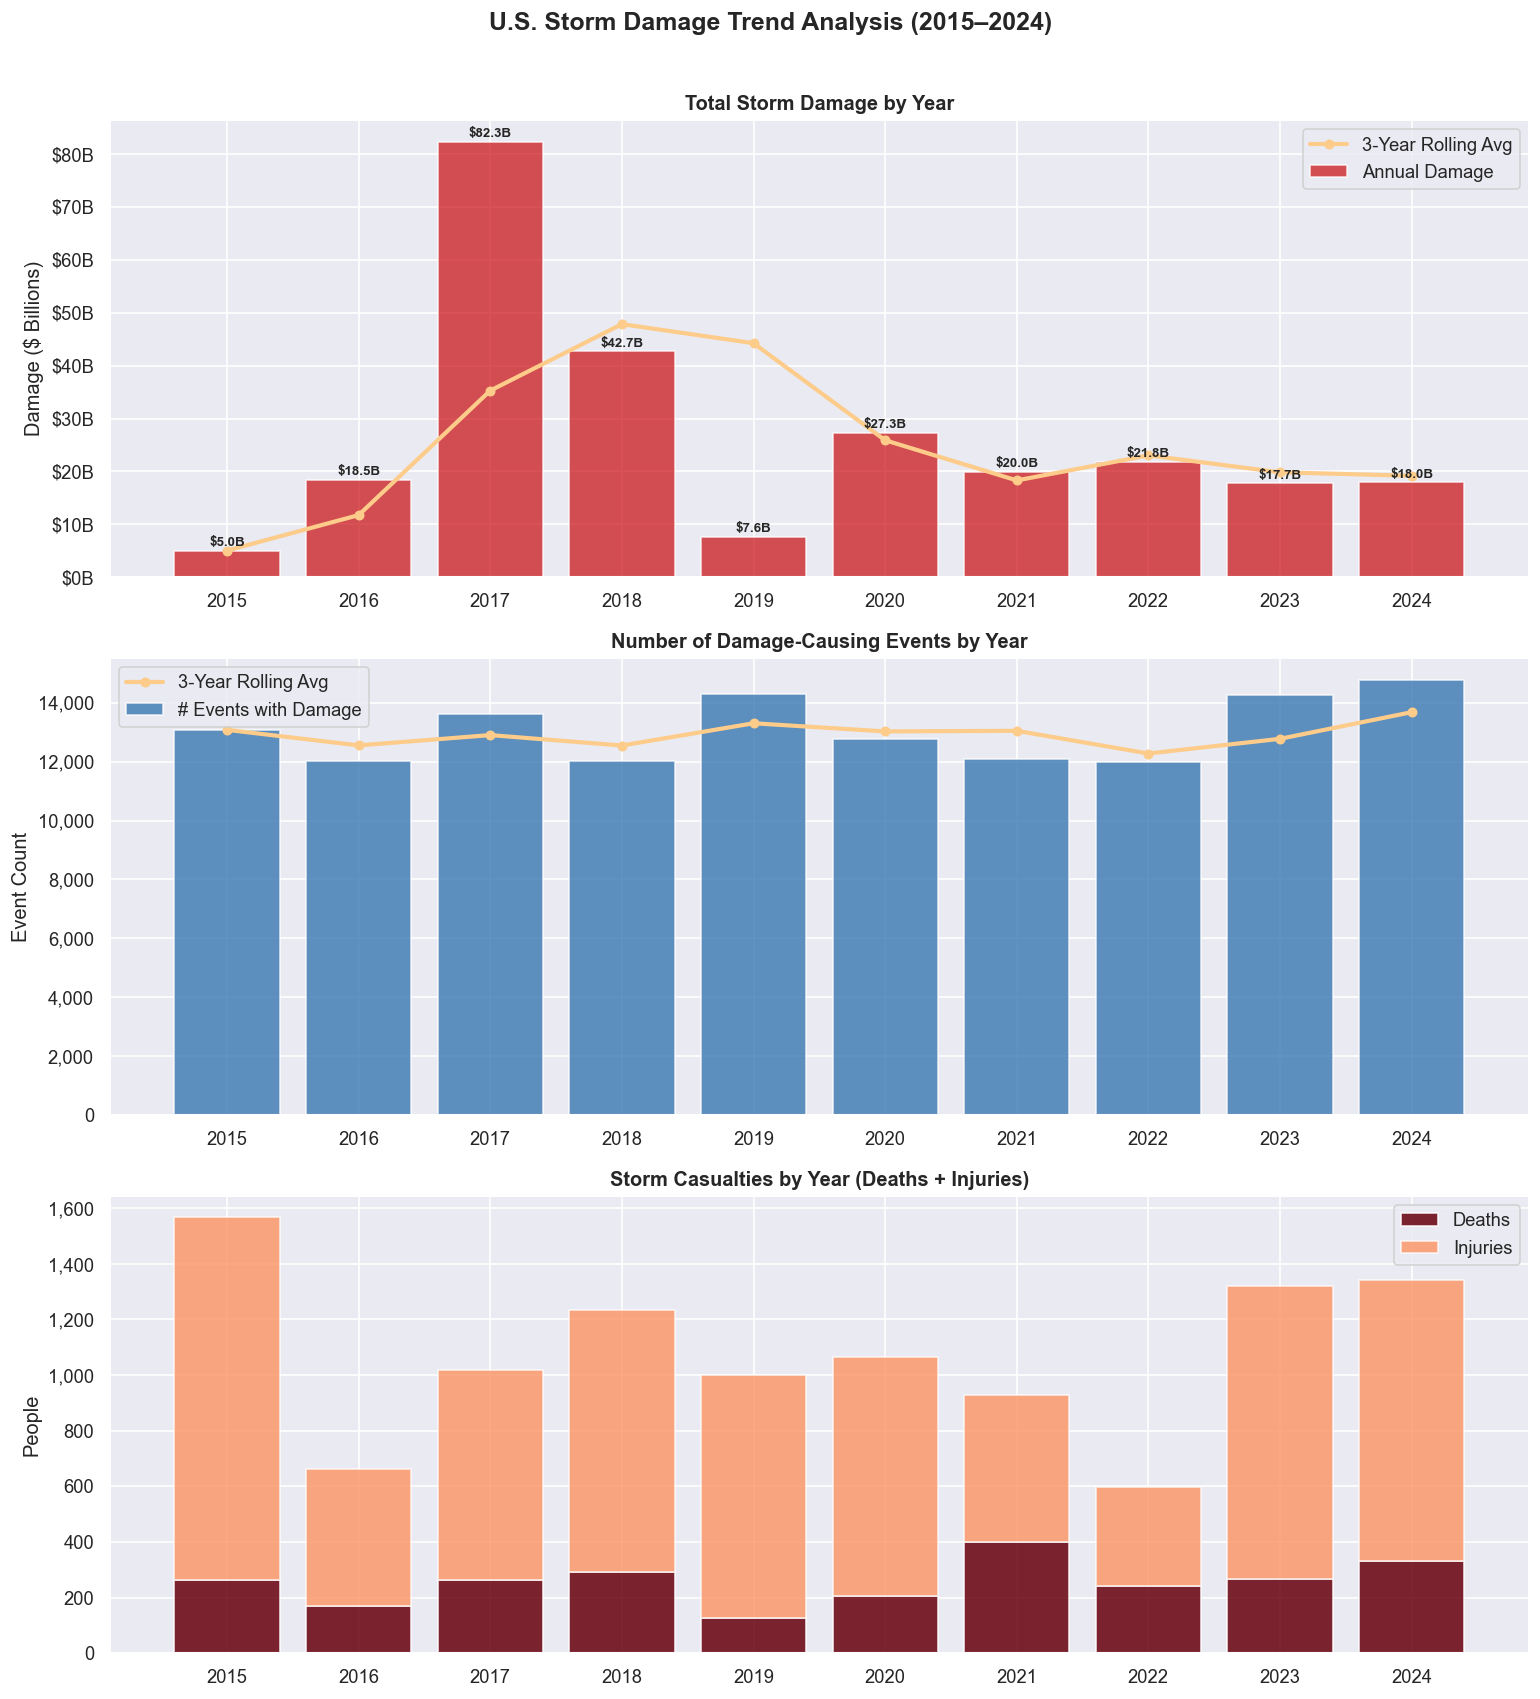

In [7]:

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

# Annual totals
annual = (
    df_damage.groupby('YEAR')
    .agg(
        Total_Damage    =('TOTAL_DAMAGE_USD',    'sum'),
        Total_Events    =('EVENT_TYPE',          'count'),
        Total_Deaths    =('TOTAL_DEATHS',        'sum'),
        Total_Injuries  =('TOTAL_INJURIES',      'sum'),
        Est_Affected    =('EST_PEOPLE_AFFECTED', 'sum')
    )
    .reset_index()
)
annual['YEAR']         = annual['YEAR'].astype(int)
annual['Rolling_3yr']  = annual['Total_Damage'].rolling(3, min_periods=1).mean()

fig, axes = plt.subplots(3, 1, figsize=(13, 14))
fig.suptitle('U.S. Storm Damage Trend Analysis (2015–2024)', fontsize=15, fontweight='bold', y=1.01)

# Plot 1: Total damage + rolling avg
ax1 = axes[0]
bars = ax1.bar(annual['YEAR'], annual['Total_Damage'] / 1e9,
               color='#cb181d', alpha=0.75, label='Annual Damage')
ax1.plot(annual['YEAR'], annual['Rolling_3yr'] / 1e9,
         color='#fdcc8a', linewidth=2.5, marker='o', markersize=5, label='3-Year Rolling Avg')
ax1.set_title('Total Storm Damage by Year', fontweight='bold')
ax1.set_ylabel('Damage ($ Billions)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax1.set_xticks(annual['YEAR'])
ax1.legend()

for bar, val in zip(bars, annual['Total_Damage']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'${val/1e9:.1f}B', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 2: Event count by year
ax2 = axes[1]
ax2.bar(annual['YEAR'], annual['Total_Events'],
        color='#2c6fad', alpha=0.75, label='# Events with Damage')
ax2.plot(annual['YEAR'],
         annual['Total_Events'].rolling(3, min_periods=1).mean(),
         color='#fdcc8a', linewidth=2.5, marker='o', markersize=5, label='3-Year Rolling Avg')
ax2.set_title('Number of Damage-Causing Events by Year', fontweight='bold')
ax2.set_ylabel('Event Count')
ax2.set_xticks(annual['YEAR'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.legend()

# Plot 3: Deaths + injuries
ax3 = axes[2]
ax3.bar(annual['YEAR'], annual['Total_Deaths'],
        color='#67000d', alpha=0.85, label='Deaths')
ax3.bar(annual['YEAR'], annual['Total_Injuries'],
        bottom=annual['Total_Deaths'],
        color='#fc8d59', alpha=0.75, label='Injuries')
ax3.set_title('Storm Casualties by Year (Deaths + Injuries)', fontweight='bold')
ax3.set_ylabel('People')
ax3.set_xticks(annual['YEAR'])
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax3.legend()

plt.tight_layout()
plt.savefig(r'C:\Users\josep\Downloads\Storm Data\trend_analysis.png', bbox_inches='tight')
plt.show()


Looking at the trend analysis, the single biggest damage year in the dataset was 2017 at $81.45 billion, which was nearly double the next worst year. This was driven almost entirely by a catastrophic flash flood season combined with Hurricanes Harvey, Irma, and Maria all making landfall in the same year. The 3-year rolling average shows that while 2017 was an outlier, damage has stayed elevated and relatively consistent since 2018, which tells me this is not a temporary spike but more of a structural trend moving upward.

What I also found interesting is the middle chart showing the number of damage causing events has stayed pretty stable between 10,000 and 14,000 per year across the entire decade. That tells us the increase in dollar damage is not because more storms are happening, it is because individual storms are getting more destructive. That is a really critical insight for anyone doing risk modeling or pricing.

Casualties peaked in 2017 and 2018 but have remained a concern every single year, with tornadoes and flash floods consistently driving the injury numbers up. 


## 5. Seasonal Patterns

C:\Users\josep\AppData\Local\Temp\ipykernel_28264\1879563979.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(month_order, rotation=45, ha='right')


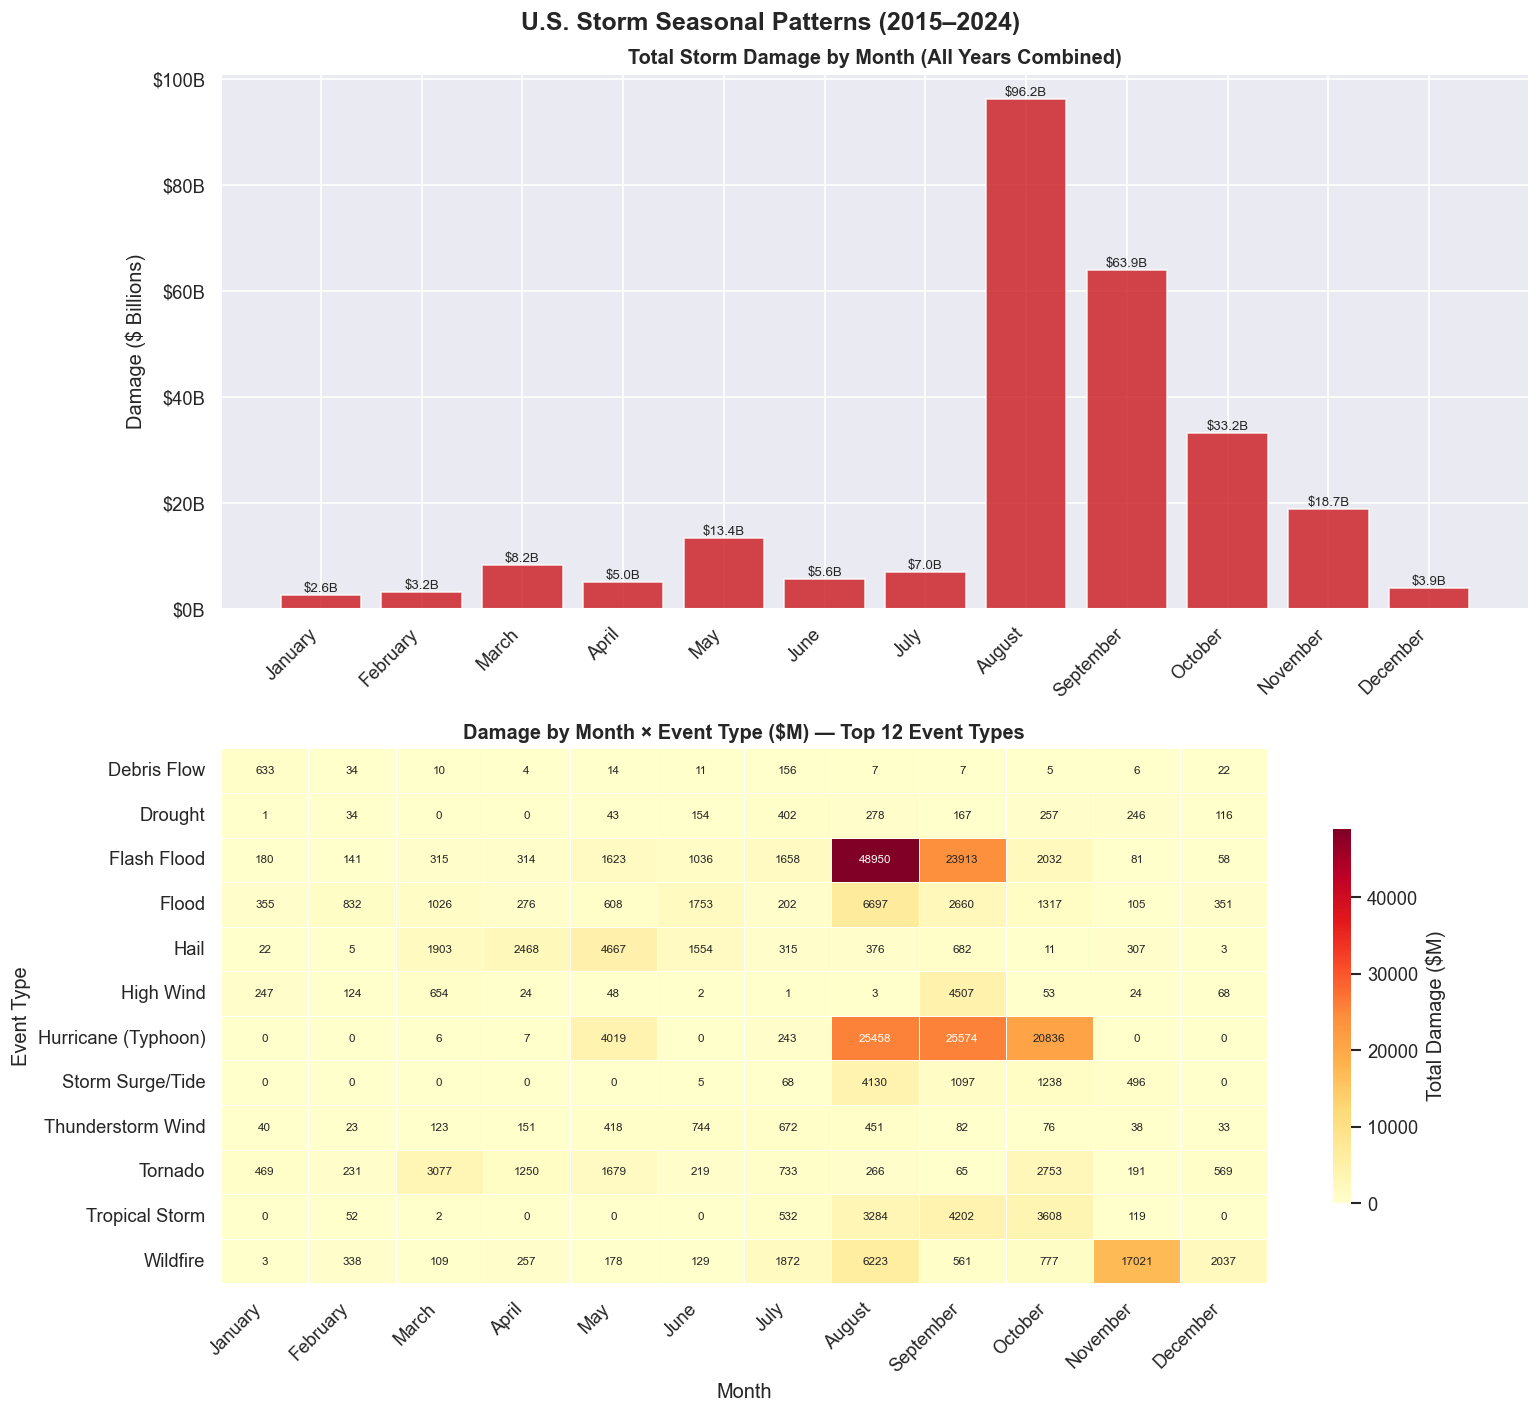

Saved: seasonal_patterns.png


In [8]:
# Month order 
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df_damage['MONTH_NAME'] = pd.Categorical(df_damage['MONTH_NAME'],
                                          categories=month_order, ordered=True)

# Monthly damage totals
monthly = (
    df_damage.groupby('MONTH_NAME', observed=True)
    .agg(Total_Damage=('TOTAL_DAMAGE_USD', 'sum'),
         Total_Events=('EVENT_TYPE',       'count'))
    .reset_index())


# Month x Event Type heatmap
top_events = (df_damage.groupby('EVENT_TYPE')['TOTAL_DAMAGE_USD']
             .sum().nlargest(12).index.tolist())

heat = (
    df_damage[df_damage['EVENT_TYPE'].isin(top_events)]
    .groupby(['MONTH_NAME', 'EVENT_TYPE'], observed=True)['TOTAL_DAMAGE_USD']
    .sum()
    .unstack(fill_value=0))


fig, axes = plt.subplots(2, 1, figsize=(13, 12))
fig.suptitle('U.S. Storm Seasonal Patterns (2015–2024)', fontsize=15, fontweight='bold')

# Plot 1: Monthly damage bar
ax1 = axes[0]
bars = ax1.bar(monthly['MONTH_NAME'], monthly['Total_Damage'] / 1e9,
               color='#cb181d', alpha=0.8)
ax1.set_title('Total Storm Damage by Month (All Years Combined)', fontweight='bold')
ax1.set_ylabel('Damage ($ Billions)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax1.set_xticklabels(month_order, rotation=45, ha='right')

for bar, val in zip(bars, monthly['Total_Damage']):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
        f'${val/1e9:.1f}B', ha='center', va='bottom', fontsize=8)

# Plot 2: Heatmap month x event type
ax2 = axes[1]
sns.heatmap(
    heat.T / 1e6,
    ax=ax2,
    cmap='YlOrRd',
    linewidths=0.3,
    cbar_kws={'label': 'Total Damage ($M)', 'shrink': 0.7},
    fmt='.0f',
    annot=True,
    annot_kws={'size': 7})

ax2.set_title('Damage by Month × Event Type ($M) — Top 12 Event Types', fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Event Type')
ax2.set_xticklabels(month_order, rotation=45, ha='right')

plt.tight_layout()
plt.savefig(r'C:\Users\josep\Downloads\Storm Data\seasonal_patterns.png', bbox_inches='tight')
plt.show()
print('Saved: seasonal_patterns.png')

The seasonal chart tells a pretty clear story. August and September are by far the most destructive months, accounting for the largest share of total damage across the entire decade. That lines up exactly with peak Atlantic hurricane season. June and July also show elevated damage driven by tornado and flash flood activity.

The heatmap breaks this down further by event type. Flash floods show damage spread across nearly every month of the year making them a year round risk. Hurricanes are heavily concentrated between August and October. Wildfires spike in the fall, particularly October. This kind of seasonal concentration has major implications for how insurers and emergency services should be staffing up and positioning resources ahead of time.


## 6. State-Level Deep Dive

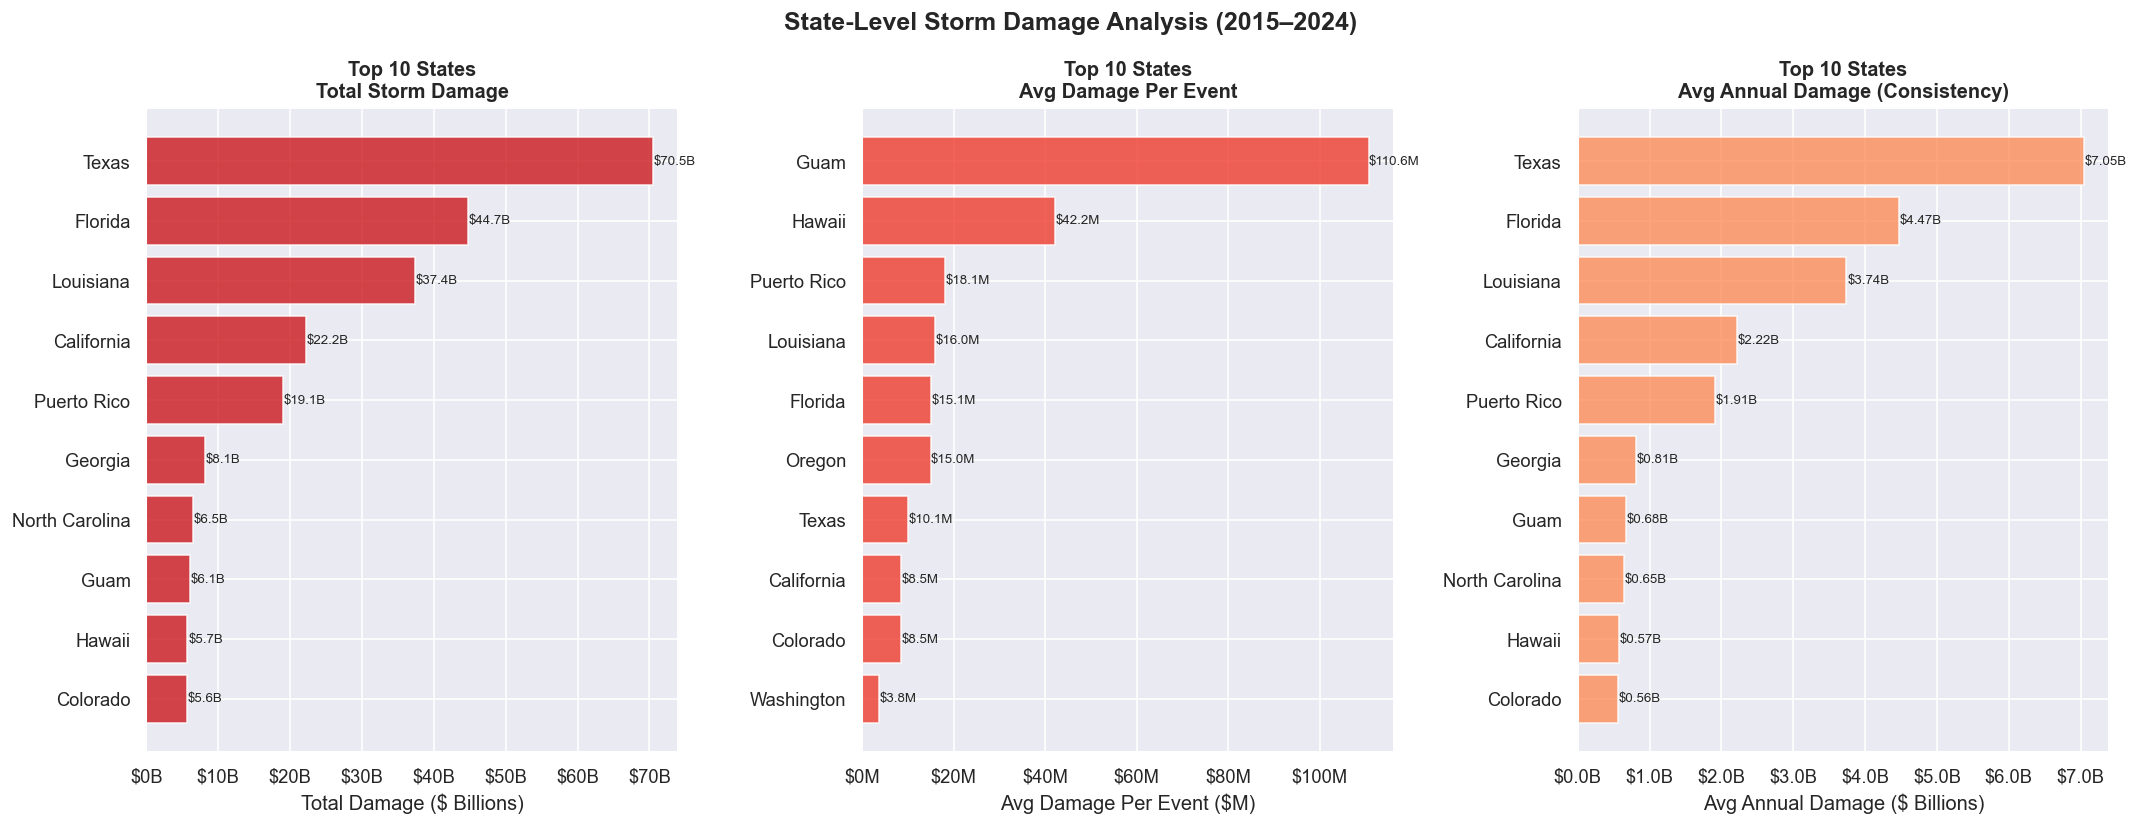

In [9]:
# State aggregation 
state_summary = (
    df_damage.groupby('STATE')
    .agg(
        Total_Damage      =('TOTAL_DAMAGE_USD',    'sum'),
        Total_Events      =('EVENT_TYPE',          'count'),
        Total_Deaths      =('TOTAL_DEATHS',        'sum'),
        Total_Injuries    =('TOTAL_INJURIES',      'sum'),
        Est_Affected      =('EST_PEOPLE_AFFECTED', 'sum'),
        Unique_Years      =('YEAR',                'nunique'))
        .reset_index())


state_summary['Avg_Damage_Per_Event'] = (
    state_summary['Total_Damage'] / state_summary['Total_Events'])

state_summary['Avg_Annual_Damage'] = (
    state_summary['Total_Damage'] / state_summary['Unique_Years'])


top10_total   = state_summary.nlargest(10, 'Total_Damage')
top10_per_evt = state_summary.nlargest(10, 'Avg_Damage_Per_Event')
top10_consist = state_summary.nlargest(10, 'Avg_Annual_Damage')

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('State-Level Storm Damage Analysis (2015–2024)',
             fontsize=15, fontweight='bold')

# Plot 1: Top 10 total damage
ax1 = axes[0]
sorted1 = top10_total.sort_values('Total_Damage')
bars1 = ax1.barh(sorted1['STATE'], sorted1['Total_Damage'] / 1e9,
                 color='#cb181d', alpha=0.8)
ax1.set_title('Top 10 States\nTotal Storm Damage', fontweight='bold')
ax1.set_xlabel('Total Damage ($ Billions)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
for bar, val in zip(bars1, sorted1['Total_Damage']):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'${val/1e9:.1f}B', va='center', fontsize=8)

# Plot 2: Highest damage per event 
ax2 = axes[1]
sorted2 = top10_per_evt.sort_values('Avg_Damage_Per_Event')
bars2 = ax2.barh(sorted2['STATE'], sorted2['Avg_Damage_Per_Event'] / 1e6,
                 color='#ef3b2c', alpha=0.8)
ax2.set_title('Top 10 States\nAvg Damage Per Event', fontweight='bold')
ax2.set_xlabel('Avg Damage Per Event ($M)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
for bar, val in zip(bars2, sorted2['Avg_Damage_Per_Event']):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'${val/1e6:.1f}M', va='center', fontsize=8)

# Plot 3: Most consistently damaged 
ax3 = axes[2]
sorted3 = top10_consist.sort_values('Avg_Annual_Damage')
bars3 = ax3.barh(sorted3['STATE'], sorted3['Avg_Annual_Damage'] / 1e9,
                 color='#fc8d59', alpha=0.8)
ax3.set_title('Top 10 States\nAvg Annual Damage (Consistency)', fontweight='bold')
ax3.set_xlabel('Avg Annual Damage ($ Billions)')
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}B'))
for bar, val in zip(bars3, sorted3['Avg_Annual_Damage']):
    ax3.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'${val/1e9:.2f}B', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(r'C:\Users\josep\Downloads\Storm Data\state_analysis.png', bbox_inches='tight')
plt.show()


At the state level, Texas leads in total storm damage by a pretty significant margin, followed by Florida, Louisiana, California, and Puerto Rico. Those five states alone account for a disproportionate share of the nation's total storm losses over the decade.

The middle chart tells a different story. When you look at average damage per event, states like Hawaii, Puerto Rico, and Louisiana rank the highest. So while Texas has the most events overall, some of these smaller states are experiencing individually catastrophic events that are far more severe on a per incident basis.

The consistency chart on the right shows which states face elevated damage every single year, and Texas and Florida stand out again here. That means these are not one time events for these states, they are persistent and recurring exposures that have to be planned around.


## 7. Human Impact vs Financial Impact

In [10]:

# Prep 
event_impact = (
    df_damage.groupby('EVENT_TYPE')
    .agg(
        Total_Damage   =('TOTAL_DAMAGE_USD',    'sum'),
        Total_Events   =('EVENT_TYPE',          'count'),
        Total_Deaths   =('TOTAL_DEATHS',        'sum'),
        Total_Injuries =('TOTAL_INJURIES',      'sum'),
        Est_Affected   =('EST_PEOPLE_AFFECTED', 'sum')
    )
    .reset_index()
)
event_impact['Total_Human_Impact'] = event_impact['Total_Deaths'] + event_impact['Total_Injuries']
event_impact = event_impact[
    (event_impact['Total_Damage'] > 1e6) |
    (event_impact['Total_Human_Impact'] > 10)
].reset_index(drop=True)

top12  = event_impact.nlargest(12, 'Total_Damage').sort_values('Total_Damage', ascending=False)
top12h = event_impact.nlargest(12, 'Total_Human_Impact').sort_values('Total_Human_Impact', ascending=False)

# Figure 
fig = make_subplots(rows=2, cols=1, vertical_spacing=0.18,
    subplot_titles=(
        'Financial Damage vs. Est. People Affected',
        'Injuries vs. Deaths by Event Type'
    )
)

# Plot 1 
fig.add_trace(go.Bar(
    name='Total Damage ($B)', x=top12['EVENT_TYPE'], y=top12['Total_Damage'] / 1e9,
    marker_color='#2c6fad', opacity=0.85,
    hovertemplate='<b>%{x}</b><br>Total Damage: $%{y:.2f}B<extra></extra>'
), row=1, col=1)

fig.add_trace(go.Bar(
    name='Est. People Affected (M)', x=top12['EVENT_TYPE'], y=top12['Est_Affected'] / 1e6,
    marker_color='#fc8d59', opacity=0.85,
    hovertemplate='<b>%{x}</b><br>Est. People Affected: %{y:.2f}M<extra></extra>'
), row=1, col=1)

fig.add_trace(go.Scatter(
    name='Deaths', x=top12['EVENT_TYPE'], y=top12['Total_Deaths'],
    mode='lines+markers+text', line=dict(color='red', width=2.5),
    marker=dict(size=8), text=top12['Total_Deaths'].astype(int),
    textposition='top center', textfont=dict(color='white', size=9),
    hovertemplate='<b>%{x}</b><br>Deaths: %{y:,}<extra></extra>'
), row=1, col=1)

# Plot 2
fig.add_trace(go.Bar(
    name='Injuries', x=top12h['EVENT_TYPE'], y=top12h['Total_Injuries'],
    marker_color='#cb181d', opacity=0.85,
    hovertemplate='<b>%{x}</b><br>Injuries: %{y:,}<extra></extra>'
), row=2, col=1)

fig.add_trace(go.Bar(
    name='Deaths ', x=top12h['EVENT_TYPE'], y=top12h['Total_Deaths'],
    marker_color='#67000d', opacity=0.85,
    hovertemplate='<b>%{x}</b><br>Deaths: %{y:,}<extra></extra>'
), row=2, col=1)

fig.add_trace(go.Scatter(
    name='Death Trend', x=top12h['EVENT_TYPE'], y=top12h['Total_Deaths'],
    mode='lines+markers+text', line=dict(color='red', width=2.5, dash='dot'),
    marker=dict(size=8), text=top12h['Total_Deaths'].astype(int),
    textposition='top center', textfont=dict(color='white', size=9),
    hovertemplate='<b>%{x}</b><br>Deaths: %{y:,}<extra></extra>'
), row=2, col=1)

# Layout 
fig.update_layout(
    title=dict(text='<b>Human Impact vs. Financial Impact (2015–2024)</b>', x=0.5),
    height=900, template='plotly_dark', barmode='group', hovermode='x unified',
    legend=dict(orientation='h', y=1.02, x=0.5, xanchor='center')
)
fig.update_xaxes(showgrid=False, tickangle=-35, tickfont=dict(size=9))
fig.update_yaxes(showgrid=False)

OUTPUT = r'C:\Users\josep\Downloads\Storm Data\human_vs_financial_interactive.html'
fig.write_html(OUTPUT)
fig.show()


This chart is honestly one of my favorite findings in the entire analysis because it highlights something that I think gets overlooked a lot. Financial damage and human casualties do not always come from the same events.

Flash floods and hurricanes dominate the financial damage side, but tornadoes are the deadliest and most injurious event type by a significant margin. Tornadoes accounted for over 4,000 injuries across the decade, which represents roughly 43% of all storm related injuries in the dataset. Their death toll of 314 makes up approximately 17% of all storm fatalities over the same period, and that is coming from an event type that only accounts for about 12% of total financial damage. That gap between human cost and financial cost is exactly what makes tornadoes such a unique and dangerous risk category. Thunderstorm winds follow closely behind in terms of injuries, contributing another 18% of total injuries across the decade.

That gap really matters. A community or insurer that is only focused on dollar damage might underinvest in tornado preparedness because the financial losses look smaller on paper. But when nearly 1 in 5 storm related injuries comes from thunderstorm winds and tornadoes combined, the human cost tells a completely different story. Effective risk management has to account for both dimensions at the same time.


## 8. Event Type Profiles


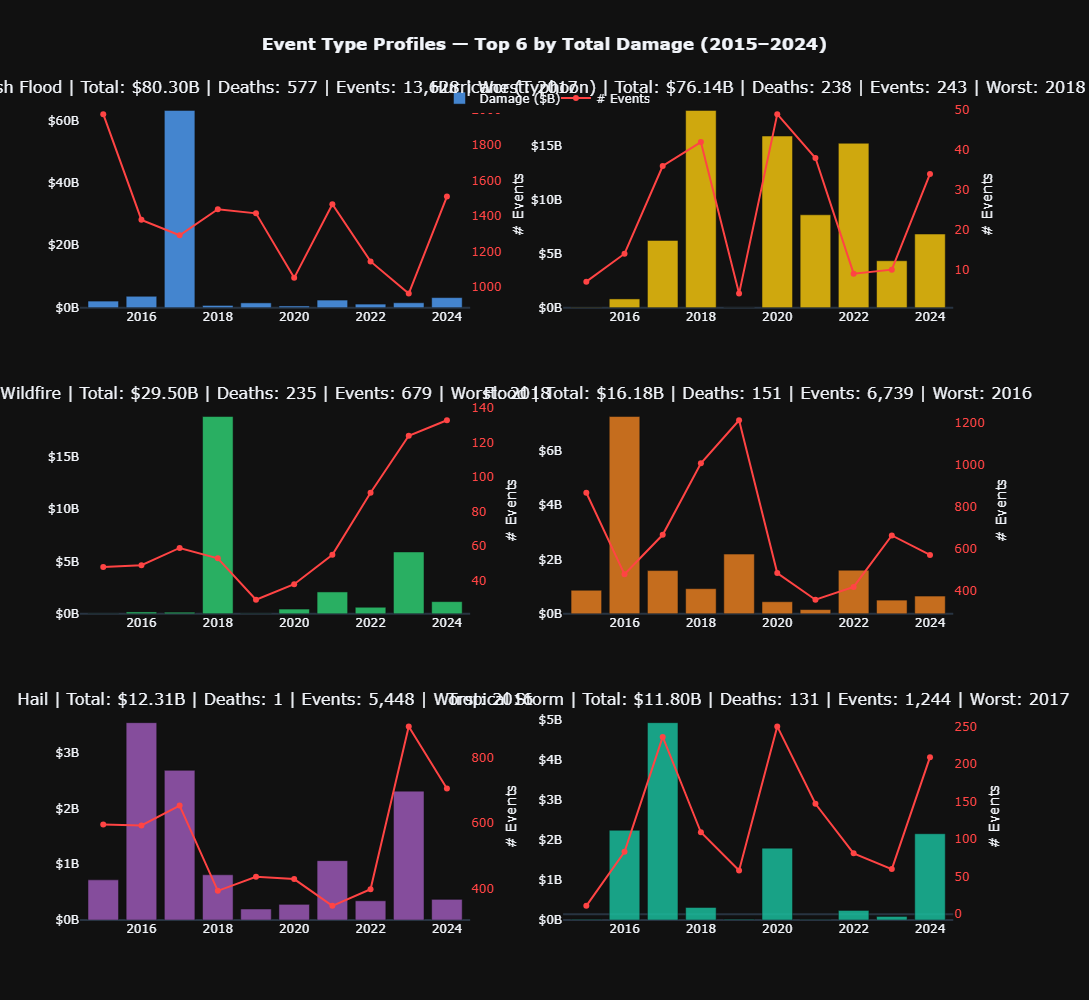

In [12]:
top6_types = df_damage.groupby('EVENT_TYPE')['TOTAL_DAMAGE_USD'].sum().nlargest(6).index.tolist()

annual_event = (
    df_damage[df_damage['EVENT_TYPE'].isin(top6_types)]
    .groupby(['YEAR','EVENT_TYPE'])
    .agg(Total_Damage=('TOTAL_DAMAGE_USD','sum'), Total_Events=('EVENT_TYPE','count'),
         Total_Deaths=('TOTAL_DEATHS','sum'), Est_Affected=('EST_PEOPLE_AFFECTED','sum'))
    .reset_index())

annual_event['YEAR'] = annual_event['YEAR'].astype(int)

colors = ['#4e9af1','#f1c40f','#2ecc71','#e67e22','#9b59b6','#1abc9c']

# Build subplot titles with summary stats 
titles = []
for e in top6_types:
    evt = annual_event[annual_event['EVENT_TYPE'] == e]
    worst = int(evt.loc[evt['Total_Damage'].idxmax(), 'YEAR'])
    titles.append(
        f"{e} | Total: {fmt_dmg(evt['Total_Damage'].sum())} | "
        f"Deaths: {int(evt['Total_Deaths'].sum()):,} | "
        f"Events: {int(evt['Total_Events'].sum()):,} | Worst: {worst}"
)

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=titles,
    vertical_spacing=0.12,
    horizontal_spacing=0.1,
    specs=[[{'secondary_y': True}, {'secondary_y': True}],
           [{'secondary_y': True}, {'secondary_y': True}],
           [{'secondary_y': True}, {'secondary_y': True}]])

for idx, (event_type, color) in enumerate(zip(top6_types, colors)):
    row, col = idx // 2 + 1, idx % 2 + 1
    evt = annual_event[annual_event['EVENT_TYPE'] == event_type]
    show_legend = idx == 0

# Damage bars 
    fig.add_trace(
        go.Bar(
            name='Damage ($B)', x=evt['YEAR'], y=evt['Total_Damage'] / 1e9,
            marker_color=color, opacity=0.85, showlegend=show_legend,
            hovertemplate='<b>%{x}</b><br>Damage: $%{y:.2f}B<extra></extra>'
        ),
        row=row, col=col, secondary_y=False)

#Events line 
    fig.add_trace(
        go.Scatter(
            name='# Events', x=evt['YEAR'], y=evt['Total_Events'],
            mode='lines+markers', line=dict(color='#ff4444', width=2),
            marker=dict(size=6), showlegend=show_legend,
            hovertemplate='<b>%{x}</b><br>Events: %{y:,}<extra></extra>'
        ),
        row=row, col=col, secondary_y=True)

# Layout
fig.update_layout(
    title=dict(text='<b>Event Type Profiles — Top 6 by Total Damage (2015–2024)</b>', x=0.5),
    height=1000, template='plotly_dark', hovermode='x unified',
    legend=dict(orientation='h', y=1.02, x=0.5, xanchor='center')
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False, secondary_y=False, tickprefix='$', ticksuffix='B')
fig.update_yaxes(showgrid=False, secondary_y=True,  title_text='# Events', tickfont=dict(color='#ff4444'))

OUTPUT = r'C:\Users\josep\Downloads\Storm Data\event_profiles_interactive.html'
fig.write_html(OUTPUT)
fig.show()

Looking at the top 6 event types by total damage gives us the clearest picture of where risk is actually concentrated across the country.

Flash floods are the single most damaging event type at $80.3 billion over the decade, representing 30.8% of all storm damage recorded between 2015 and 2024. With 577 deaths and 13,628 total events, they are both the most frequent and most financially destructive category in the dataset. 2017 was by far their worst year, and that was largely driven by Hurricane Harvey's rainfall totals.

Hurricanes caused $76.14 billion in damage across just 243 events, making up 29.2% of total decade damage from only a fraction of the total event count. To put that in perspective, flash floods occurred over 13,000 times to reach a similar damage total while hurricanes reached nearly the same number in just 243 events. 2022 stands out here, with Hurricane Ian driving a massive single year spike.

Wildfires account for $29.5 billion, or about 11.3% of total damage and show honestly the most alarming trend in the entire dataset. Damage was relatively contained through 2017, then exploded in 2018 with the Camp Fire in California and has stayed elevated every year since. Their death toll of 235 represents 12.8% of all storm fatalities in the dataset despite being far less frequent than events like flash floods or thunderstorm winds. That is the clearest evidence of an accelerating risk category I found in this entire analysis.

Floods contributed $16.18 billion or 6.2% of total damage across 6,739 events, making 2016 their worst year. Hail added another 12.31 billion, or 4.7% spread fairly evenly across the decade with notably low casualties despite high financial impact. Tropical storms round out the top 6 at 11.8 billion, or 4.5% of total damage, with 2017 being their worst year driven by the active hurricane season converting to tropical storm classifications inland.


## 9. Summary: What does this actually mean in practice?

#### So What? — Key Takeaways & Real World Applications

**For Insurers:** For an insurer, this analysis immediately highlights which states and event types deserve the most attention when it comes to pricing, reserve setting, and catastrophe modeling. Texas and Florida are not just high volume markets. They are high severity markets with consistent annual exposure that has to be reflected in how risk is priced and managed. Wildfires represent a growing tail risk that older models may not be fully capturing yet. But beyond just understanding past damage, insurers can use this data proactively. Knowing that August and September consistently account for the largest share of annual damage, an insurer can make sure their catastrophe response teams are fully staffed, their reinsurance treaties are in place, and their claims processing capacity is scaled up before that window even opens. That kind of calendar driven preparation directly reduces response time and ultimately reduces total loss costs when a major event does hit.

**For FEMA and Emergency Services:** The seasonal concentration in August and September combined with the geographic clustering along the Gulf Coast and Southeast tells you exactly where pre positioned resources will have the highest impact. The same way a retailer stocks shelves before a holiday rush, emergency managers can use this data to pre stage equipment, personnel, and supplies in high risk corridors before peak storm season arrives rather than reacting after the fact. The human impact data on tornadoes also suggests that early warning systems and shelter infrastructure deserve investment completely independent of financial loss metrics. Tornadoes making up 17% of all storm fatalities while representing only 12% of financial damage means the human cost is being underweighted if decisions are driven by dollars alone.

**For City Planners and Local Governments:** The flash flood data is really hard to ignore. With 13,628 events over a decade and $80 billion in total damage representing nearly 31% of all storm losses, flood mitigation infrastructure like drainage systems, flood barriers, and smart zoning has an enormous potential return on investment. Cities in high frequency flash flood states can use the monthly damage patterns in this data to time infrastructure maintenance and emergency protocol reviews ahead of their peak risk months rather than waiting until damage has already occurred. A city in Louisiana or Texas that knows August is historically their most damaging month has a roadmap for when to have every flood gate inspected, every drainage channel cleared, and every emergency shelter ready to open.

**For Financial Institutions and Investment Firms:** Understanding storm damage concentration by geography and season can directly inform decisions around real estate portfolios, municipal bond risk in storm prone areas, and even catastrophe bond pricing. A portfolio heavily weighted toward Gulf Coast real estate carries a materially different risk profile in August than it does in February and this data makes that timing quantifiable.

**What Comes Next:** In terms of what I would do next with more data, I would want to bring in actual insurance claims data to validate these damage estimates, layer in climate projection models to forecast which event types are likely to grow, and incorporate population migration data since people continuing to move into high risk areas like Florida and Texas is directly increasing future exposure every year. Pairing historical storm patterns with forward looking climate and demographic data would allow any of these institutions to move from reactive planning to truly predictive risk management.

**Limitations:** On the limitations side I want to be very clear that NOAA data only captures reported events, so rural areas and underreported incidents likely mean these numbers actually understate true damage. Damage estimates submitted to NOAA can also vary in accuracy across counties and reporting agencies, so these figures should be treated as the best available approximation rather than precise measurements.

**Overall:** What this analysis shows me is that U.S. storm damage is not random. It is concentrated by geography, season, and event type in ways that are entirely predictable and actionable with the right data and the right analytical approach. The institutions that treat this as a planning tool rather than just a historical record are the ones that will be best positioned when the next major event hits.